<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/Lekcia/Ulana_2805_pandas_tasks_beginners_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практичні завдання з pandas для початківців

**Мета:** Набути базових навичок роботи з бібліотекою pandas для аналізу табличних даних.

**Інструкції:**
- Виконуйте завдання послідовно — кожне наступне спирається на попередні.
- Після виконання кожного завдання напишіть короткий висновок у комірці `**Висновок:**`.
- Не змінюйте код у комірках з підготовкою даних.

**Набір даних:** Умовна таблиця продажів інтернет-магазину за 2023 рік.

---
## Підготовка: Генерація тестових даних

Запустіть цю комірку перед початком роботи. Не змінюйте код.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

categories = ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт']
cities = ['Київ', 'Харків', 'Одеса', 'Дніпро', 'Львів']
payment_methods = ['Картка', 'Готівка', 'Онлайн']

df = pd.DataFrame({
    'order_id':        range(1001, 1001 + n),
    'date':            pd.date_range('2023-01-01', periods=n, freq='D')[:n],
    'category':        np.random.choice(categories, n),
    'product':         ['Товар_' + str(i) for i in np.random.randint(1, 51, n)],
    'city':            np.random.choice(cities, n),
    'quantity':        np.random.randint(1, 10, n),
    'price':           np.round(np.random.uniform(50, 5000, n), 2),
    'payment_method':  np.random.choice(payment_methods, n),
    'rating':          np.random.choice([1, 2, 3, 4, 5, np.nan], n, p=[0.05, 0.1, 0.15, 0.3, 0.3, 0.1]),
    'is_returned':     np.random.choice([True, False], n, p=[0.1, 0.9]),
})

# Додаємо кілька пропущених значень
df.loc[np.random.choice(df.index, 10, replace=False), 'city'] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), 'price'] = np.nan

# Розраховуємо загальну суму
df['total'] = df['quantity'] * df['price']

print('Дані успішно згенеровано. Рядків:', len(df))
print('Колонки:', list(df.columns))

Дані успішно згенеровано. Рядків: 200
Колонки: ['order_id', 'date', 'category', 'product', 'city', 'quantity', 'price', 'payment_method', 'rating', 'is_returned', 'total']


---
## Завдання 1 (Легке). Перший погляд на дані

Виведіть перші 10 рядків датафрейму `df` та отримайте загальну інформацію про нього (кількість рядків, колонок, типи даних) за допомогою методів `head()` та `info()`.

In [2]:
# Ваш код тут
display(df.head())
df.iloc[1:3, 5:8]
df.info()


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total
0,1001,2023-01-01,Продукти,Товар_34,Київ,1,963.38,Картка,5.0,False,963.38
1,1002,2023-01-02,Спорт,Товар_6,Львів,6,1086.28,Картка,4.0,False,6517.68
2,1003,2023-01-03,Книги,Товар_22,Дніпро,4,1883.84,Готівка,5.0,False,7535.36
3,1004,2023-01-04,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39
4,1005,2023-01-05,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        200 non-null    int64         
 1   date            200 non-null    datetime64[ns]
 2   category        200 non-null    object        
 3   product         200 non-null    object        
 4   city            190 non-null    object        
 5   quantity        200 non-null    int64         
 6   price           195 non-null    float64       
 7   payment_method  200 non-null    object        
 8   rating          177 non-null    float64       
 9   is_returned     200 non-null    bool          
 10  total           195 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 15.9+ KB


**Висновок:** *(Напишіть, скільки рядків і колонок у датафреймі, які типи даних зустрічаються, чи є пропущені значення)*

---
## Завдання 2 (Легке). Описова статистика

Використайте метод `describe()` для отримання описової статистики числових колонок. Окремо виведіть мінімум, максимум і середнє значення колонки `price`.

In [3]:
# Ваш код тут
df.describe()

,order_id,date,quantity,price,rating,total
count,200.000000,200,200.000000,195.000000,177.000000,195.000000
mean,1100.500000,2023-04-10 12:00:00,4.700000,2500.579641,3.813559,11629.097590
min,1001.000000,2023-01-01 00:00:00,1.000000,139.650000,1.000000,149.350000
25%,1050.750000,2023-02-19 18:00:00,2.000000,1288.215000,3.000000,3893.955000
50%,1100.500000,2023-04-10 12:00:00,5.000000,2517.290000,4.000000,8746.840000
75%,1150.250000,2023-05-30 06:00:00,7.000000,3706.975000,5.000000,16922.420000
max,1200.000000,2023-07-19 00:00:00,9.000000,4950.300000,5.000000,44324.640000
std,57.879185,NaN,2.618066,1380.066748,1.169808,9968.293697


**Висновок:** *(Опишіть діапазон цін, середнє значення, чи є суттєвий розкид)*

---
## Завдання 3 (Легке). Пропущені значення

Знайдіть кількість пропущених значень у кожній колонці за допомогою `isnull().sum()`. Визначте, який відсоток рядків має пропущені значення хоча б в одній колонці (`dropna()` та `len()`).

In [4]:
# Ваш код тут
df.isnull().sum()

,0
order_id,0
date,0
category,0
product,0
city,10
quantity,0
price,5
payment_method,0
rating,23
is_returned,0


**Висновок:** *(У яких колонках є пропуски, наскільки це критично для аналізу)*

---
## Завдання 4 (Легке). Відбір колонок і рядків

Створіть новий датафрейм `df_subset`, що містить лише колонки `order_id`, `category`, `city`, `total`. Потім виведіть рядки з індексами від 10 до 20 включно за допомогою `.iloc[]`.

In [5]:
# Ваш код тут
df_subset = df[['order_id', 'category', 'city', 'total']]
df_subset.iloc[10:21, 1:]
df_subset[[ 'category', 'city', 'total']]
df_subset

,order_id,category,city,total
0,1001,Продукти,Київ,963.38
1,1002,Спорт,Львів,6517.68
2,1003,Книги,Дніпро,7535.36
3,1004,Спорт,Дніпро,2448.39
4,1005,Спорт,Дніпро,21772.52
...,...,...,...,...
195,1196,Книги,Львів,10473.00
196,1197,Книги,Львів,2976.81
197,1198,Електроніка,Львів,16200.48
198,1199,Спорт,Одеса,321.07


**Висновок:** *(Поясніть різницю між вибором колонок через список і через `iloc`)*

---
## Завдання 5 (Легке). Фільтрація даних

Відфільтруйте датафрейм і отримайте:
1. Всі замовлення з категорії `'Електроніка'`.
2. Всі замовлення, де `price` перевищує 2000.
3. Поверненi замовлення (`is_returned == True`) з міста `'Київ'`.

Виведіть кількість рядків для кожного фільтру.

In [6]:
# Ваш код тут
print(len(df[df['category']=='Електроніка'])/df.shape[0]*100)
#print(df.shape, df.size, len(df))
#df[df['price']>2000]
print(df[(df['is_returned']==True) & (df['city']== 'Київ')].shape[0]/df[df['is_returned']==True].shape[0]*100)
print(df[(df['is_returned']==True) & (df['city']== 'Київ')].shape[0]/df[df['city']== 'Київ'].shape[0]*100)
print(df['city'].unique())
returned_by_city = df.groupby('city').agg(count_= ('order_id', 'count'), is_ret = ('is_returned', 'sum'))
returned_by_city['percent'] = (returned_by_city['is_ret']/returned_by_city['count_']*100).round(2)
display(returned_by_city.sort_values(by='percent'))


21.5
28.000000000000004
18.91891891891892
['Київ' 'Львів' 'Дніпро' 'Одеса' 'Харків' nan]


,count_,is_ret,percent
city,,,
Дніпро,38,2,5.26
Харків,39,3,7.69
Львів,46,5,10.87
Київ,37,7,18.92
Одеса,30,7,23.33


**Висновок:** *(Яка частка замовлень відповідає кожному критерію? Що можна сказати про повернення з Києва?)*

---
## Завдання 6 (Середнє). Сортування та ранжування

1. Відсортуйте датафрейм за колонкою `total` у спадному порядку та виведіть топ-10 найбільших замовлень.
2. Додайте нову колонку `rank`, що містить порядковий номер замовлення за розміром суми (від найбільшого до найменшого) за допомогою `.rank()`.

In [7]:
# Ваш код тут

df['rank'] = df['total'].rank(ascending=False, method = 'min')
df.sort_values('total', ascending=False).head(10)

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
190,1191,2023-07-10,Одяг,Товар_22,Київ,9,4924.96,Готівка,4.0,True,44324.64,1.0
58,1059,2023-02-28,Продукти,Товар_33,Харків,9,4848.88,Картка,5.0,False,43639.92,2.0
186,1187,2023-07-06,Спорт,Товар_34,Київ,9,4675.12,Готівка,5.0,False,42076.08,3.0
55,1056,2023-02-25,Електроніка,Товар_3,Дніпро,8,4912.77,Картка,5.0,False,39302.16,4.0
169,1170,2023-06-19,Продукти,Товар_50,Київ,8,4739.05,Готівка,5.0,False,37912.40,5.0
191,1192,2023-07-11,Спорт,Товар_25,Харків,9,4202.55,Готівка,4.0,True,37822.95,6.0
193,1194,2023-07-13,Одяг,Товар_22,NaN,8,4608.17,Картка,4.0,False,36865.36,7.0
51,1052,2023-02-21,Продукти,Товар_35,Дніпро,8,4488.99,Онлайн,4.0,False,35911.92,8.0
25,1026,2023-01-26,Книги,Товар_18,Дніпро,8,4458.11,Картка,3.0,False,35664.88,9.0
143,1144,2023-05-24,Продукти,Товар_31,Київ,9,3732.53,Готівка,5.0,False,33592.77,10.0


**Висновок:** *(Яка максимальна сума замовлення? З яких категорій найбільші замовлення?)*

---
## Завдання 7 (Середнє). Групування та агрегація

За допомогою `groupby()` розрахуйте для кожної категорії товарів:
- загальний обсяг продажів (сума `total`),
- кількість замовлень,
- середню ціну (`price`).

Відсортуйте результат за загальним обсягом продажів.

,total_sum,total_count,price_mean
category,,,
Продукти,583761.68,47,2513.979787
Одяг,474135.61,34,2707.906176
Електроніка,428129.79,43,2334.470698
Спорт,400802.56,35,2494.205143
Книги,380844.39,36,2491.881944


,total,price
category,,
Електроніка,43,2334.470698
Книги,36,2491.881944
Одяг,34,2707.906176
Продукти,47,2513.979787
Спорт,35,2494.205143


<Axes: xlabel='category'>

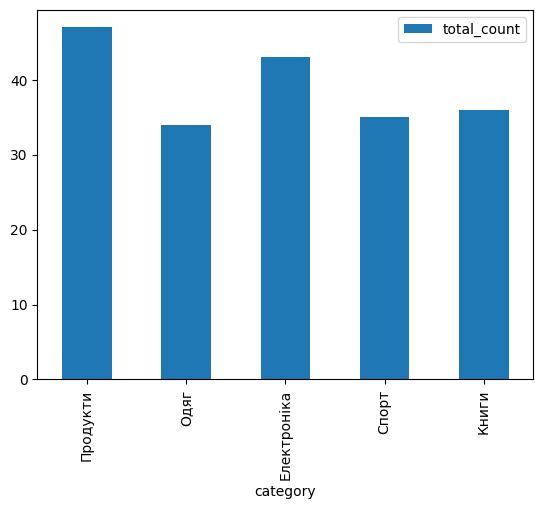

In [8]:
# Ваш код тут
#display(df.groupby('category')['total'].sum())
#display(df.groupby('category')['total'].count())
#display(df.groupby('category')['price'].mean())

display(df.groupby('category').agg(total_sum = ('total', 'sum'), total_count = ('total', 'count'), price_mean = ('price','mean')).sort_values('total_sum', ascending=False))
display(df.groupby('category').agg({'total' : 'sum',
                                    'total' : 'count',
                                    'price':'mean'}))
df.groupby('category').agg(total_sum = ('total', 'sum'),
                           total_count = ('total', 'count'),
                           price_mean = ('price','mean')).sort_values('total_sum', ascending=False).plot(kind ='bar', y = 'total_count')

**Висновок:** *(Яка категорія приносить найбільший дохід? Чи збігається це з кількістю замовлень?)*

---
## Завдання 8 (Середнє). Обробка пропущених значень

1. Заповніть пропущені значення в колонці `price` медіаною цін відповідної категорії (використайте `groupby().transform('median')`).
2. Заповніть пропущені значення в колонці `city` рядком `'Невідомо'`.
3. Пропущені значення в `rating` залиште без змін — поясніть чому у висновку.

Перевірте, що пропусків у `price` та `city` більше немає.

In [9]:
# Ваш код тут
display(df[df['price'].isna()])
median_price = df.groupby('category')['price'].transform('median')
display(median_price)
df['price'] = df['price'].fillna(median_price)
df['total'] = df['total'].fillna(df['price']*df['quantity'])
df['city'] = df['city'].fillna('Невідомо')
display(df[df['rating'].isna()].sort_values('product'))

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
22,1023,2023-01-23,Продукти,Товар_33,Харків,9,NaN,Картка,5.0,False,NaN,NaN
52,1053,2023-02-22,Продукти,Товар_19,Харків,5,NaN,Онлайн,3.0,False,NaN,NaN
66,1067,2023-03-08,Одяг,Товар_20,Одеса,3,NaN,Готівка,5.0,False,NaN,NaN
72,1073,2023-03-14,Спорт,Товар_29,Харків,2,NaN,Готівка,5.0,False,NaN,NaN
117,1118,2023-04-28,Книги,Товар_49,Львів,7,NaN,Онлайн,5.0,True,NaN,NaN


,price
0,2740.590
1,2448.390
2,2461.385
3,2448.390
4,2448.390
...,...
195,2461.385
196,2461.385
197,2025.060
198,2448.390


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
5,1006,2023-01-06,Одяг,Товар_16,Львів,9,1876.12,Онлайн,NaN,False,16885.08,50.0
140,1141,2023-05-21,Електроніка,Товар_18,Київ,3,800.79,Онлайн,NaN,True,2402.37,172.0
75,1076,2023-03-17,Одяг,Товар_18,Одеса,5,3072.57,Картка,NaN,False,15362.85,59.0
153,1154,2023-06-03,Електроніка,Товар_2,Дніпро,1,2016.57,Готівка,NaN,False,2016.57,177.0
156,1157,2023-06-06,Продукти,Товар_2,Дніпро,8,1184.79,Онлайн,NaN,False,9478.32,87.0
76,1077,2023-03-18,Електроніка,Товар_2,Невідомо,7,1478.72,Картка,NaN,False,10351.04,83.0
106,1107,2023-04-17,Книги,Товар_21,Харків,1,741.87,Онлайн,NaN,False,741.87,191.0
104,1105,2023-04-15,Електроніка,Товар_27,Львів,5,2893.64,Онлайн,NaN,False,14468.20,67.0
136,1137,2023-05-17,Продукти,Товар_32,Львів,6,3119.36,Онлайн,NaN,False,18716.16,38.0
48,1049,2023-02-18,Одяг,Товар_32,Київ,9,973.51,Готівка,NaN,False,8761.59,97.0


**Висновок:** *(Чому медіана краща за середнє для заповнення цін? Чому пропуски в rating можна залишити?)*

---
## Завдання 9 (Середнє). Додавання обчислюваних колонок

Додайте до датафрейму нові колонки:
1. `month` — місяць замовлення (з колонки `date`).
2. `price_category` — категорія ціни: `'Низька'` (до 500), `'Середня'` (500–2000), `'Висока'` (понад 2000). Використайте `pd.cut()` або `np.select()`.
3. `discount_total` — сума зі знижкою 15%.

/tmp/ipykernel_1939/787190907.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = df.groupby('price_category').agg(total_sum = ('total', 'sum'),
/tmp/ipykernel_1939/787190907.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('price_category').agg(total_sum = ('total', 'sum'),


,total_sum,count_
price_category,,
Низька,129018.03,40
Середня,322878.09,39
Висока,1884129.81,121


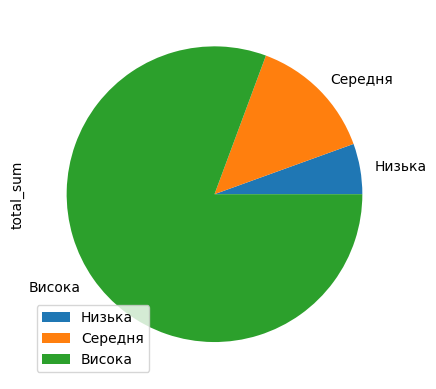

In [10]:
# Ваш код тут
import numpy as np
df['month'] = df['date'].dt.month
df['price_category'] = pd.cut(df['price'], bins = [0, 1000, 2000, float('inf')], labels = ['Низька', 'Середня', 'Висока'])
df['price_category2'] = np.select([df['price']<500, (df['price'] >= 500) & (df['price'] <= 2000), df['price']>2000], ['Низька','Середня',  'Висока'], default = '')
df['discount_total'] = (df['total']*0.85).round(2)
x = df.groupby('price_category').agg(total_sum = ('total', 'sum'),
                                         count_ = ('order_id', 'count')).plot(kind='pie', y= 'total_sum')
display(df.groupby('price_category').agg(total_sum = ('total', 'sum'),
                                         count_ = ('order_id', 'count')))

**Висновок:** *(Який розподіл цінових категорій? Як метод pd.cut спрощує категоризацію?)*

---
## Завдання 10 (Середнє). Зведена таблиця (pivot table)

Побудуйте зведену таблицю за допомогою `pd.pivot_table()`, де:
- рядки — `city`,
- колонки — `category`,
- значення — сума `total`,
- агрегація — `sum`.

Додайте підсумки по рядках і колонках (`margins=True`).

In [11]:
# Ваш код тут
pd.pivot_table(
  df,
  index = 'city',
  columns = 'category',
  values = 'total',
  aggfunc= 'sum',
  margins = True
)

category,Електроніка,Книги,Одяг,Продукти,Спорт,All
city,,,,,,
Дніпро,65438.16,116118.970,31179.870,147336.56,72244.38,432317.940
Київ,58713.88,87339.030,103754.430,118283.10,113742.95,481833.390
Львів,154285.60,126188.885,74340.690,55768.80,43155.08,453739.055
Невідомо,21012.44,25984.450,46962.310,40508.03,5917.59,140384.820
Одеса,84611.65,26773.570,90218.245,60466.75,65539.34,327609.555
Харків,44068.06,15669.180,135537.230,199766.70,105100.00,500141.170
All,428129.79,398074.085,481992.775,622129.94,405699.34,2336025.930


**Висновок:** *(Яке місто і яка категорія дають найбільший сумарний дохід? Що показують margins?)*

---
## Завдання 11 (Середнє). Підрахунок унікальних значень і частот

1. Підрахуйте кількість унікальних товарів (`product`) у кожній категорії.
2. Виведіть топ-5 найпопулярніших товарів за кількістю замовлень за допомогою `value_counts()`.
3. Визначте частку кожного способу оплати у відсотках (`normalize=True`).

In [12]:
# Ваш код тут


**Висновок:** *(Який спосіб оплати найпопулярніший? Чи рівномірний розподіл між способами?)*

---
## Завдання 12 (Середнє). Аналіз повернень

Розрахуйте рівень повернень (частку повернених замовлень) для кожної категорії та кожного міста. Визначте:
- категорію з найвищим рівнем повернень,
- місто з найнижчим рівнем повернень.

Підказка: використайте `groupby()['is_returned'].mean()`.

In [13]:
# Ваш код тут


**Висновок:** *(Яка категорія найчастіше повертається? Про що це може свідчити?)*

---
## Завдання 13 (Підвищена складність). Часовий аналіз

1. Встановіть колонку `date` як індекс датафрейму.
2. Розрахуйте щомісячний обсяг продажів (ресемплінг `resample('ME')` або `resample('M')`, sum по `total`).
3. Знайдіть найкращий і найгірший місяці за продажами.
4. Поверніть звичайний числовий індекс (`reset_index()`).

In [14]:
# Ваш код тут


**Висновок:** *(Який місяць виявився найуспішнішим? Чи є сезонність у даних?)*

---
## Завдання 14 (Підвищена складність). Накопичувальні показники

1. Відсортуйте датафрейм за датою.
2. Додайте колонку `cumulative_total` — накопичувальний обсяг продажів з початку року (`cumsum()`).
3. Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.

In [15]:
# Ваш код тут


**Висновок:** *(Коли приблизно була зароблена половина річного доходу? Що це означає для бізнесу?)*

---
## Завдання 15 (Підвищена складність). apply() та lambda

1. Використайте `apply()` з lambda-функцією для створення колонки `total_with_tax`, де ПДВ становить 20%, але лише для замовлень на суму понад 1000 (решта — без змін).
2. Напишіть функцію `classify_rating(r)`, що повертає `'Поганий'` (1–2), `'Нейтральний'` (3), `'Хороший'` (4–5), `'Без оцінки'` (NaN). Застосуйте її до колонки `rating`.

In [16]:
# Ваш код тут


**Висновок:** *(Яка частка замовлень має хороший рейтинг? Коли apply кращий за vectorized-операції?)*

---
## Завдання 16 (Підвищена складність). Злиття датафреймів (merge)

Створіть додатковий датафрейм `df_discounts` з колонками `category` та `discount_pct` (різні знижки для кожної категорії). Об'єднайте його з основним датафреймом за допомогою `pd.merge()` та розрахуйте `final_total` — суму після застосування відповідної знижки.

```python
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})
```

In [17]:
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})

# Ваш код тут


**Висновок:** *(Яка категорія отримала найбільшу сумарну знижку? Коли варто використовувати merge замість map?)*

---
## Завдання 17 (Підвищена складність). Групові трансформації

1. Додайте колонку `city_avg_total` — середня сума замовлення по місту (для кожного рядка підставте середнє по його місту), використайте `groupby().transform('mean')`.
2. Додайте колонку `above_city_avg` — булева колонка, що показує, чи перевищує замовлення середнє по місту.
3. Підрахуйте частку таких замовлень для кожного міста.

In [18]:
# Ваш код тут


**Висновок:** *(Чим transform відрізняється від звичайного groupby? У якому місті найбільша частка великих замовлень?)*

---
## Завдання 18 (Складне). Ковзне середнє та аномалії

1. Згрупуйте дані за місяцем та розрахуйте щоденну виручку.
2. Розрахуйте 7-денне ковзне середнє виручки (`rolling(7).mean()`).
3. Визначте дні-аномалії: дні, коли виручка відхилилася від ковзного середнього більш ніж на 2 стандартних відхилення.

In [19]:
# Ваш код тут


**Висновок:** *(Скільки аномальних днів виявлено? Що може бути причиною різких відхилень виручки?)*

---
## Завдання 19 (Складне). Когортний аналіз

Виконайте спрощений когортний аналіз за місяцем першого замовлення:
1. Для кожного товару (`product`) знайдіть місяць першого продажу — це його «когорта».
2. Об'єднайте цю інформацію з основним датафреймом.
3. Побудуйте зведену таблицю: когорта (місяць першого продажу) проти місяця замовлення, значення — кількість замовлень.

Підказка: використайте `groupby('product')['date'].transform('min')` та `dt.to_period('M')`.

In [20]:
# Ваш код тут


**Висновок:** *(Що показує когортна таблиця? Чи продовжують товари з першої когорти продаватися в наступних місяцях?)*

---
## Завдання 20 (Складне). Підсумковий звіт

Сформуйте підсумковий звіт у вигляді одного датафрейму `summary_report`, що містить для кожної категорії:
- загальний дохід (`total_revenue`),
- кількість замовлень (`order_count`),
- середній чек (`avg_order_value`),
- частку доходу від загального (`revenue_share_pct`),
- рівень повернень у відсотках (`return_rate_pct`),
- середній рейтинг без NaN (`avg_rating`).

Відсортуйте за `total_revenue` спадно. Збережіть результат у файл `summary_report.csv`.

In [21]:
# Ваш код тут


**Висновок:** *(Яка категорія є лідером за доходом? Чи є зв'язок між рейтингом та рівнем повернень? Які рекомендації можна дати бізнесу на основі цього звіту?)*

---
## Загальні підсумки

Після виконання всіх завдань дайте відповідь на такі питання:

1. Які методи pandas виявилися для вас найбільш корисними?
2. Які труднощі виникли під час роботи з пропущеними значеннями?
3. Що можна додати до аналізу, щоб зробити його більш повним?

*(Ваші відповіді тут)*